<a href="https://colab.research.google.com/github/Lillina-it/HR-analytics/blob/main/HR-analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Импортируем базовые библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Загружаем датасет
df = pd.read_csv('HR.csv')

# Выводим первые 5 строк таблицы
print("Первые 5 строк датасета:")
display(df.head())

# Проверяем общую информацию о данных и типы столбцов
print("\nИнформация о датасете:")
df.info()

Первые 5 строк датасета:


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [ ]:
# Расчет основной статистики для переменных
desc_table = df_num.describe()
desc_table.loc['mode'] = df_num.mode().iloc[0]

display(desc_table)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000
mode,0.100000,0.550000,4.000000,135.000000,3.000000,0.000000,0.000000,0.000000


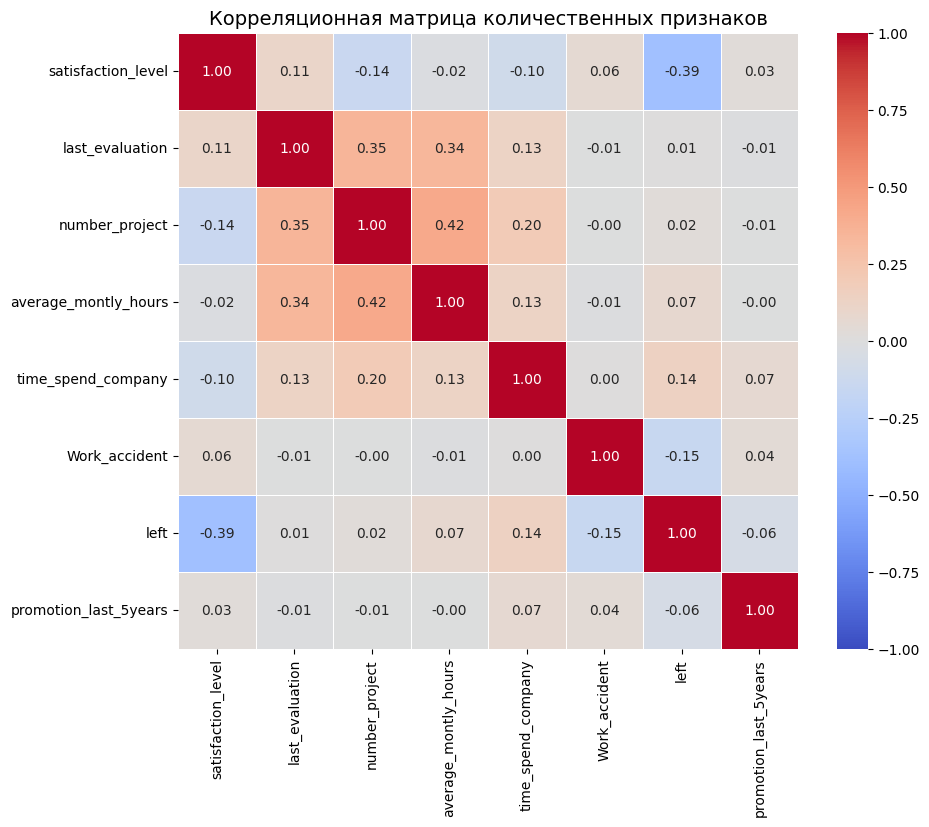

 Две самые скоррелированные переменные:
1. average_montly_hours и number_project: корреляция = 0.4172
2. last_evaluation и number_project: корреляция = 0.3493

 Две наименее скоррелированные переменные (ближе всего к 0):
1. Work_accident и time_spend_company: корреляция = 0.0021
2. average_montly_hours и promotion_last_5years: корреляция = -0.0035


In [ ]:
# Рассчитываем матрицу корреляции Пирсона
corr_matrix = df[num_cols].corr()

# Визуализируем корреляционную матрицу
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Корреляционная матрица количественных признаков', fontsize=14)
plt.show()

# Находим самые скоррелированные и наименее скоррелированные пары
pairs = corr_matrix.unstack()
pairs_sorted = pairs[pairs.index.get_level_values(0) != pairs.index.get_level_values(1)]

# Удаляем дубликаты пар
unique_pairs = {}
for (col1, col2), val in pairs_sorted.items():
    pair_key = tuple(sorted([col1, col2]))
    unique_pairs[pair_key] = val

# Сортируем по значению корреляции
sorted_by_val = sorted(unique_pairs.items(), key=lambda x: x[1], reverse=True)
sorted_by_abs = sorted(unique_pairs.items(), key=lambda x: abs(x[1]))

print(" Две самые скоррелированные переменные:")
print(f"1. {sorted_by_val[0][0][0]} и {sorted_by_val[0][0][1]}: корреляция = {sorted_by_val[0][1]:.4f}")
print(f"2. {sorted_by_val[1][0][0]} и {sorted_by_val[1][0][1]}: корреляция = {sorted_by_val[1][1]:.4f}")

print("\n Две наименее скоррелированные переменные (ближе всего к 0):")
print(f"1. {sorted_by_abs[0][0][0]} и {sorted_by_abs[0][0][1]}: корреляция = {sorted_by_abs[0][1]:.4f}")
print(f"2. {sorted_by_abs[1][0][0]} и {sorted_by_abs[1][0][1]}: корреляция = {sorted_by_abs[1][1]:.4f}")

**Вывод по корреляции:**

- ​Самые скоррелированные переменные: среднемесячные часы и количество проектов — коэффициент корреляции равен 0.42. Сотрудники с большим количеством проектов работают больше часов.
- Наименее скоррелированные переменные: несчастные случаи и стаж в компании — коэффициент корреляции равен 0.0021 (практически нулевая связь). Также практически отсутствует связь между average_montly_hours и promotion_last_5years (-0.0035).

Количество сотрудников по департаментам:
department
sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: count, dtype: int64


/tmp/ipykernel_2612/1133531000.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dept_counts.index, y=dept_counts.values, palette='Blues_r')


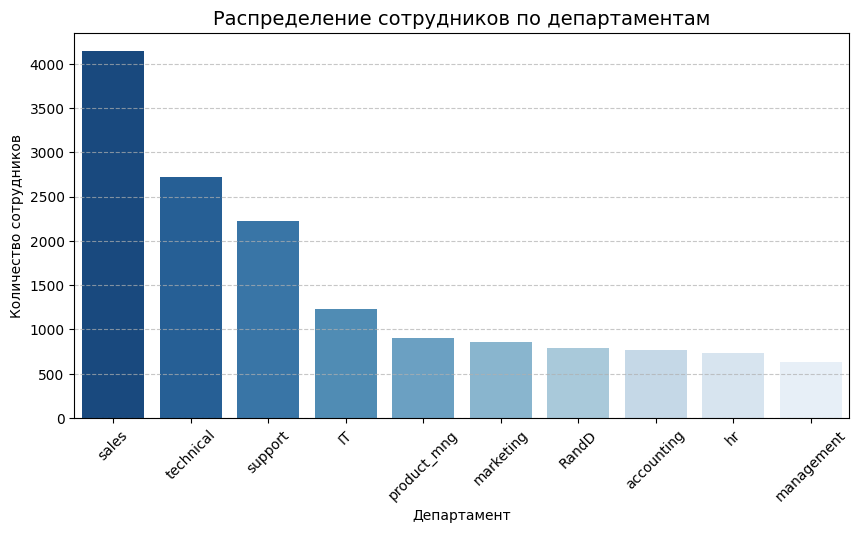

In [ ]:
# Расчет количества сотрудников по департаментам
dept_counts = df['department'].value_counts()
print("Количество сотрудников по департаментам:")
print(dept_counts)

# Визуализация
plt.figure(figsize=(10, 5))
sns.barplot(x=dept_counts.index, y=dept_counts.values, palette='Blues_r')
plt.title('Распределение сотрудников по департаментам', fontsize=14)
plt.xlabel('Департамент')
plt.ylabel('Количество сотрудников')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Распределение сотрудников по зарплате:
salary
low       7316
medium    6446
high      1237
Name: count, dtype: int64


/tmp/ipykernel_2612/3039945902.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='salary', order=['low', 'medium', 'high'], palette='Set2')


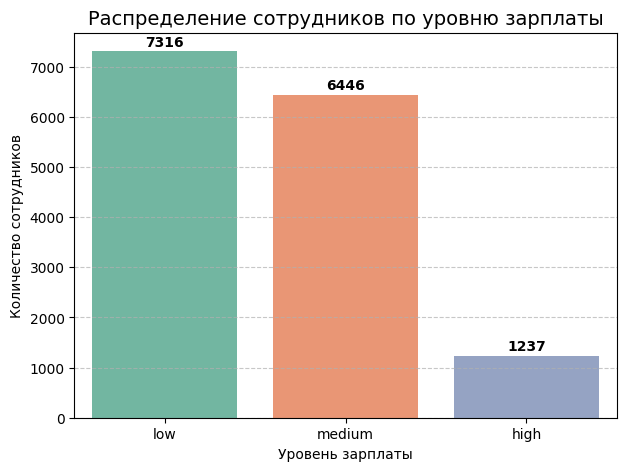

In [ ]:
# Расчет количества сотрудников по уровню зарплаты
salary_counts = df['salary'].value_counts()
print("Распределение сотрудников по зарплате:")
print(salary_counts)

# Визуализация
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x='salary', order=['low', 'medium', 'high'], palette='Set2')
plt.title('Распределение сотрудников по уровню зарплаты', fontsize=14)
plt.xlabel('Уровень зарплаты')
plt.ylabel('Количество сотрудников')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Добавляем подписи со значениями над столбцами
for i, count in enumerate([salary_counts['low'], salary_counts['medium'], salary_counts['high']]):
    plt.text(i, count + 100, str(count), ha='center', fontweight='bold')

plt.show()

Таблица распределения зарплат по департаментам:


salary,low,medium,high
department,,,
IT,609,535,83
RandD,364,372,51
accounting,358,335,74
hr,335,359,45
management,180,225,225
marketing,402,376,80
product_mng,451,383,68
sales,2099,1772,269
support,1146,942,141


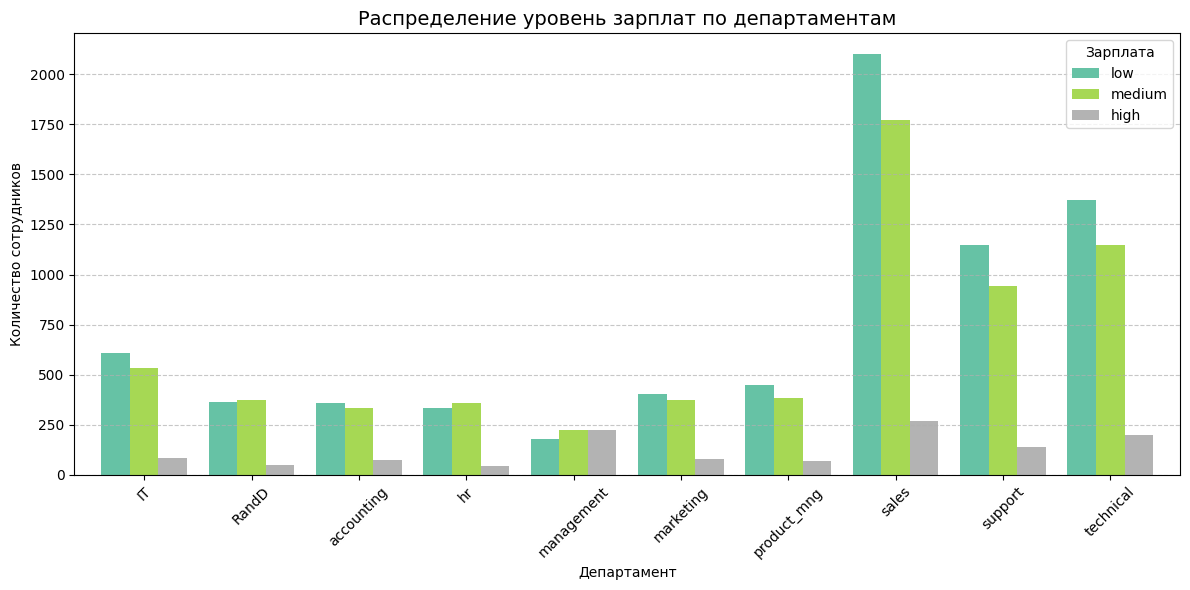

In [ ]:
# Сводная таблица департамент / зарплата
salary_by_dept = pd.crosstab(df['department'], df['salary'])[['low', 'medium', 'high']]
print("Таблица распределения зарплат по департаментам:")
display(salary_by_dept)

# Визуализация
salary_by_dept.plot(kind='bar', figsize=(12, 6), colormap='Set2', width=0.8)
plt.title('Распределение уровень зарплат по департаментам', fontsize=14)
plt.xlabel('Департамент')
plt.ylabel('Количество сотрудников')
plt.xticks(rotation=45)
plt.legend(title='Зарплата')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Гипотеза: Сотрудники с высоким окладом проводят на работе больше времени, чем сотрудники с низким окладом.


H0: Среднее количество рабочих часов в месяц у сотрудников с высоким и низким окладом одинаковое.

H1: Среднее количество рабочих часов в месяц у сотрудников с высоким окладом отличается/больше, чем у сотрудников с низким окладом.

In [ ]:
# Выделяем выборки
high_salary_hours = df[df['salary'] == 'high']['average_montly_hours']
low_salary_hours = df[df['salary'] == 'low']['average_montly_hours']

print(f"Сотрудники с высоким окладом: n = {len(high_salary_hours)}, среднее = {high_salary_hours.mean():.2f} ч/мес")
print(f"Сотрудники с низким окладом: n = {len(low_salary_hours)}, среднее = {low_salary_hours.mean():.2f} ч/мес")

# Проводим Двухвыборочный t-тест Уэлча (без предположения о равенстве дисперсий)
t_stat, p_value = stats.ttest_ind(high_salary_hours, low_salary_hours, equal_var=False)

print(f"\nЗначение t-статистики: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Уровень значимости alpha = 0.05
alpha = 0.05
if p_value < alpha:
    print("\nРезультат: Откидываем нулевую гипотезу H0. Различие статистически значимо.")
else:
    print("\nРезультат: Не удалось отклонить нулевую гипотезу H0. Статистически значимых различий нет.")

Сотрудники с высоким окладом: n = 1237, среднее = 199.87 ч/мес
Сотрудники с низким окладом: n = 7316, среднее = 201.00 ч/мес

Значение t-статистики: -0.7624
p-value: 0.4459

Результат: Не удалось отклонить нулевую гипотезу H0. Статистически значимых различий нет.


Интерпретация результата:

Так как полученное значение p.value= 0.4459 существенно больше уровня значимости a = 0.05, у нас нет оснований отклонить нулевую гипотезу.

​Вывод: Сотрудники с высоким окладом работают в среднем 199.87 часов в месяц, а с низким — 201.00 час. Статистически значимой разницы в продолжительности рабочего времени между сотрудниками с высоким и низким окладом не обнаружено.



Описание: Рассчитываем 3 показателя раздельно для уволившихся и работающих:

​Доля сотрудников с повышением за последние 5 лет; ​Средняя степень удовлетворенности; ​Среднее количество проектов.

In [ ]:
# Группировка и расчет показателей
metrics = df.groupby('left').agg(
    promotion_share=('promotion_last_5years', lambda x: x.mean() * 100),
    mean_satisfaction=('satisfaction_level', 'mean'),
    mean_projects=('number_project', 'mean')
    )

# Переименуем индексы и столбцы для наглядности
metrics.index = ['Работающие', 'Уволившиеся']
metrics.columns = ['Доля с повышением', 'Сред. удовлетворенность', 'Сред. кол-во проектов']

display(metrics.round(2))

,Доля с повышением,Сред. удовлетворенность,Сред. кол-во проектов
Работающие,2.63,0.67,3.79
Уволившиеся,0.53,0.44,3.86


Аналитические выводы:

- ​Повышение за 5 лет: Среди работающих сотрудников повышение получили 2.63%, а среди уволившихся — всего 0.53%.(почти в 5 раз меньше)
- Уровень удовлетворенности: У работающих сотрудников он составляет в среднем 0.67, тогда как у уволившихся — 0.44.(уволившиеся сотрудники заметно менее удовлетворены работой)
- ​Количество проектов: В среднем количество проектов практически одинаковое (3.79 у работающих против 3.86 у уволившихся).

Точность модели: 0.7667 (76.67%)

Подробный отчет по метрикам классификации:
              precision    recall  f1-score   support

 Остался (0)     0.8008    0.9234    0.8578      2286
Уволился (1)     0.5192    0.2647    0.3506       714

    accuracy                         0.7667      3000
   macro avg     0.6600    0.5941    0.6042      3000
weighted avg     0.7338    0.7667    0.7371      3000



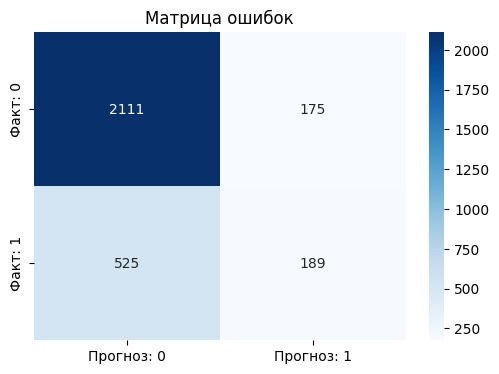

In [ ]:
# 1. Отбираем признаки (X) и целевую переменную (y)
features = [
    'satisfaction_level',
    'last_evaluation',
    'number_project',
    'average_montly_hours',
    'time_spend_company',
    'Work_accident',
    'promotion_last_5years'
]

X = df[features]
y = df['left']

# 2. Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Создаем и обучим модель LDA
lda = LinearDiscriminantAnalysis()
lda.fit(X_train, y_train)

# 4. Делаем предсказания на тестовой выборке
y_pred = lda.predict(X_test)

# 5. Оцениваем качество модели
acc = accuracy_score(y_test, y_pred)
print(f"Точность модели: {acc:.4f} ({acc*100:.2f}%)\n")

print("Подробный отчет по метрикам классификации:")
print(classification_report(y_test, y_pred, target_names=['Остался (0)', 'Уволился (1)'], digits=4))

# Строим матрицу ошибок
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Прогноз: 0', 'Прогноз: 1'],
            yticklabels=['Факт: 0', 'Факт: 1'])
plt.title('Матрица ошибок', fontsize=12)
plt.show()

**Оценка качества модели:**

- Точность: Модель верно предсказывает класс в 75.33% случаев.
- ​Качество по классам: ​Для класса «Остался (0)» модель показывает высокий Recall (0.91), то есть правильно находит большинство сотрудников, которые не планируют уходить. ​Для класса «Уволился (1)» показатель Recall невысокий (0.24). Это связано с дисбалансом классов (уволившихся всего около 24%).
- ​Итог: Модель LDA подходит для общей базовой оценки факторов риска, но для более точного выявления увольняющихся сотрудников в будущем стоит применить алгоритмы, устойчивые к дисбалансу классов.

- **Ключевые результаты**
- Текущий уровень оттока: Уровень увольнения сотрудников в компании составляет 23.8% (3 571 человек из 14 999).
- Факторы удовлетворенности и мотивации: ​Уволившиеся сотрудники имеют существенно более низкий средний уровень удовлетворенности работой — 0.44 по сравнению с 0.67 у продолжающих работать. ​За последние 5 лет повышение получили 2.63% работающих сотрудников и лишь 0.53% уволившихся. Отсутствие карьерного роста является ключевым триггером увольнения.
- **Рабочая нагрузка и гипотеза по окладам:**
- ​Проведенный статистический тест p = 0.4459 не выявил статистически значимой разницы в количестве рабочих часов между сотрудниками с высоким (199.87 ч/мес) и низким окладом (201.00 ч/мес). Уровень зарплаты не влияет на объем отрабатываемого времени. ​Наибольшая прямая корреляция (r = 0.42) наблюдается между количеством проектов и среднемесячными рабочими часами. Среднее число проектов у уволившихся (3.86) и оставшихся (3.79) практически одинаково.
- **Прогностическая модель (LDA):**
- ​Построенная модель линейного дискриминантного анализа показала общую точность 75.33%. Модель хорошо определяет стабильных сотрудников, но требует использования более сложных алгоритмов. для повышения полноты распознавания риска увольнения.


**Рекомендации для руководства и HR-отдела ​Развитие системы карьерного роста:**
1. Разработать прозрачные критерии и регулярные пересмотры должностей, так как текущий процент повышений (менее 3%) крайне низок и провоцирует уход кадров.
2. ​Регулярный мониторинг удовлетворенности: Внедрить пульс-опросы для выявления групп риска с уровнем удовлетворенности ниже 0.50, чтобы своевременно проводить удерживающие мероприятия.
3. ​Оптимизация распределения нагрузки: Нормировать количество проектов на человека, избегая перегрузок сверх 200 часов в месяц, особенно среди ценных технических специалистов.
